In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# 데이터 선정
dataset = pd.read_csv('선형회귀_성적.csv')
# print(dataset)

    hour  score
0    0.5     10
1    1.2      8
2    1.8     14
3    2.4     26
4    2.6     22
5    3.2     30
6    3.9     42
7    4.4     48
8    4.5     38
9    5.0     58
10   5.3     60
11   5.8     72
12   6.0     62
13   6.1     68
14   6.2     72
15   6.9     58
16   7.2     76
17   8.4     86
18   8.6     90
19  10.0    100


In [13]:
# 독립변수, 종속변수 분리
X = dataset.iloc[: , :-1]
y = dataset.iloc[: , -1]

In [14]:
# 훈련,테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [23]:
# 학습
# max_iter : 훈련 세트 바복 횟수. Epoch 횟수
# eth0 : 학습률
# verbose : epoch를 할 때마자 결과를 출력
# random_state : 데이터를 랜덤하게 선택할때 사용될 기준
sgdr = SGDRegressor(max_iter=1000, eta0=1e-4, random_state=0, verbose=1)
sgdr.fit(X_train, y_train)

lr = LinearRegression()
lr.fit(X_train, y_train)

-- Epoch 1
Norm: 0.27, NNZs: 1, Bias: 0.048869, T: 16, Avg. loss: 1484.241876
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.47, NNZs: 1, Bias: 0.083896, T: 32, Avg. loss: 1419.741822
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.64, NNZs: 1, Bias: 0.114272, T: 48, Avg. loss: 1367.983092
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.79, NNZs: 1, Bias: 0.141552, T: 64, Avg. loss: 1322.870279
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.94, NNZs: 1, Bias: 0.166772, T: 80, Avg. loss: 1282.550224
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.07, NNZs: 1, Bias: 0.190476, T: 96, Avg. loss: 1245.587071
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1.20, NNZs: 1, Bias: 0.212877, T: 112, Avg. loss: 1211.227118
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 1.32, NNZs: 1, Bias: 0.234194, T: 128, Avg. loss: 1179.037565
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 1.43, NNZs: 1, Bias: 0.254556, T: 144, Avg. loss: 1148.814106
Total training 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# 예측
y_predic = sgdr.predict(X_test)

print(f'변수 값 : {X_test.squeeze().values}')
print(f'예측 값 : {y_predic}')
print(f'실제 값 : {y_test.values}')

변수 값 : [ 8.6  1.2 10.   4.5]
예측 값 : [ 90.89071251  13.96907926 105.44345394  48.27196976]
실제 값 : [ 90   8 100  38]


In [24]:
# 성능을 확인
print(f'SGD 성능 : {sgdr.score(X_test, y_test)}')
print(f'LR 성능 : {lr.score(X_test, y_test)}')

SGD 성능 : 0.9748430825252619
LR 성능 : 0.9727616474310156


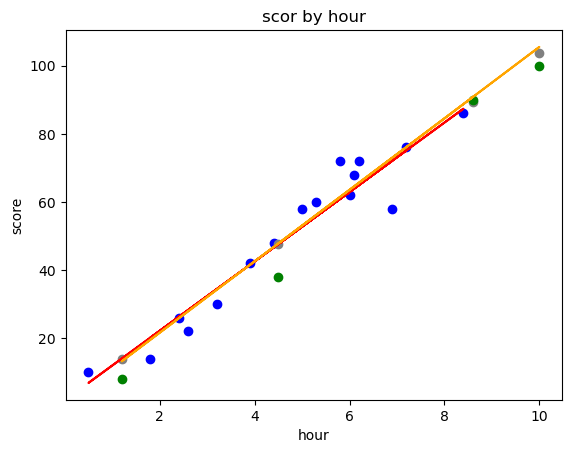

In [26]:
# 그랴프로 확인
plt.scatter(X_train, y_train, color='blue') # 훈련 데이터를 점으로 출력
plt.plot(X_train,sgdr.predict(X_train), color='red') # SGDR학슴을 통해 나온 직선
plt.plot(X_test, lr.predict(X_test), color='orange') # LR학습을 통해 나온 직선
plt.scatter(X_test, sgdr.predict(X_test), color='gray') # 테스트 데이터의 예측 데이터
plt.scatter(X_test, y_test, color='green') # 테스트 데이터의 실제 데이터
plt.title('scor by hour') # 그래프 제목
plt.xlabel('hour') # x축 => 독립변수
plt.ylabel('score') # y축 => 종속변수
plt.show() # 그래픽 출력

In [ ]:
model2 = LinearRegression() # 비교용